In [1]:
%load_ext autoreload
%autoreload 2

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data.preproces_dataset import TextCleanTransformer
from src.models.first_model import prepare_text_datasets

%matplotlib inline

In [3]:
train_csv = "../data/raw/train.csv"
test_csv = "../data/raw/test.csv"

In [4]:
X_train = pd.read_csv(train_csv)
# X_test = pd.read_csv(test_csv)

In [5]:
X_train

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1


In [6]:
X_train.text

0       Our Deeds are the Reason of this #earthquake M...
1                  Forest fire near La Ronge Sask. Canada
2       All residents asked to 'shelter in place' are ...
3       13,000 people receive #wildfires evacuation or...
4       Just got sent this photo from Ruby #Alaska as ...
                              ...                        
7608    Two giant cranes holding a bridge collapse int...
7609    @aria_ahrary @TheTawniest The out of control w...
7610    M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...
7611    Police investigating after an e-bike collided ...
7612    The Latest: More Homes Razed by Northern Calif...
Name: text, Length: 7613, dtype: object

In [7]:
X_train['text_clean'] = TextCleanTransformer().fit_transform(X_train.text.values)

In [8]:
for i in X_train.sample(100).index:
    print(f"INDEX:   {i}")
    print(f"INPUT:   {X_train['text'][i]}")
    print(f"OUTPUT:  {X_train['text_clean'][i]}\n<*>")

INDEX:   5428
INPUT:   Police: Gunman reported dead at Nashville area theater: A suspect who carried a gun and a hatchet at the Carmi... http://t.co/kqvN1uTpMM
OUTPUT:  Police gunman report dead Nashville area theater suspect carry gun hatchet Carmi
<*>
INDEX:   7454
INPUT:   Woodlawn Shooting Wounds 79-Year-Old Woman Teen - Woodlawn - http://t.co/nu3XXn55vS Chicago http://t.co/XNGrfNQSx3
OUTPUT:  Woodlawn Shooting Wounds 79 year old Woman Teen Woodlawn Chicago
<*>
INDEX:   5925
INPUT:   I just got screamed at for asking my dad to move half a step so I could get through....
OUTPUT:  got scream ask dad half step
<*>
INDEX:   451
INPUT:   it scares me that there's new versions of nuclear attack warnings like just knowing that governments still prepare for them
OUTPUT:  scare new version nuclear attack warning like know government prepare
<*>
INDEX:   4701
INPUT:   #Flashflood causes #landslide in Gilgit #Pakistan Damage to 20 homes farmland roads and bridges #365disasters  http://t.co/91

In [9]:
train_sentences = X_train['text_clean'].values
train_labels = X_train['target'].values

In [16]:
padding = 'post'
truncating = 'post'
num_words = 5000
oov_token = '<OOV>'
maxlen = 64
embeding = 300

tokenizer = {
    'num_words': num_words,
    # filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
    # lower=True,
    # split=' ',
    # char_level=False,
    'oov_token': oov_token,
    # document_count=0,
}

pad = {
    'maxlen': maxlen,
    # dtype='int32',
    'padding': padding,
    'truncating': truncating,
    # value=0.
}

X_train = prepare_text_datasets(train_sentences,
                      tokenizer=tokenizer,
                      pad=pad)

In [22]:
from src.models.first_model import model_1
model = model_1(num_words, embeding)


Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_2 (Embedding)      (None, None, 300)         1500000   
_________________________________________________________________
dropout_6 (Dropout)          (None, None, 300)         0         
_________________________________________________________________
conv1d_2 (Conv1D)            (None, None, 32)          28832     
_________________________________________________________________
max_pooling1d_2 (MaxPooling1 (None, None, 32)          0         
_________________________________________________________________
conv1d_3 (Conv1D)            (None, None, 32)          5152      
_________________________________________________________________
max_pooling1d_3 (MaxPooling1 (None, None, 32)          0         
_________________________________________________________________
dense_5 (Dense)              (None, None, 128)        

In [23]:
loss = 'binary_crossentropy'
optimizer = 'adam'
metric = ['accuracy']

model.compile(loss=loss, optimizer=optimizer, metrics=metric)
model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_2 (Embedding)      (None, None, 300)         1500000   
_________________________________________________________________
dropout_6 (Dropout)          (None, None, 300)         0         
_________________________________________________________________
conv1d_2 (Conv1D)            (None, None, 32)          28832     
_________________________________________________________________
max_pooling1d_2 (MaxPooling1 (None, None, 32)          0         
_________________________________________________________________
conv1d_3 (Conv1D)            (None, None, 32)          5152      
_________________________________________________________________
max_pooling1d_3 (MaxPooling1 (None, None, 32)          0         
_________________________________________________________________
dense_5 (Dense)              (None, None, 128)        

In [24]:
num_epochs = 10
history = model.fit(X_train,
                    train_labels,
                    epochs=num_epochs,
                    validation_split=0.2,
                    verbose=2)

Epoch 1/10
191/191 - 6s - loss: 0.6705 - accuracy: 0.5963 - val_loss: 0.6692 - val_accuracy: 0.5813
Epoch 2/10
191/191 - 5s - loss: 0.6339 - accuracy: 0.6284 - val_loss: 0.6574 - val_accuracy: 0.5825
Epoch 3/10
191/191 - 5s - loss: 0.6120 - accuracy: 0.6393 - val_loss: 0.6733 - val_accuracy: 0.5819
Epoch 4/10
191/191 - 6s - loss: 0.5964 - accuracy: 0.6460 - val_loss: 0.6944 - val_accuracy: 0.5823
Epoch 5/10
191/191 - 5s - loss: 0.5853 - accuracy: 0.6504 - val_loss: 0.7123 - val_accuracy: 0.5809
Epoch 6/10
191/191 - 5s - loss: 0.5784 - accuracy: 0.6531 - val_loss: 0.7491 - val_accuracy: 0.5792
Epoch 7/10
191/191 - 5s - loss: 0.5726 - accuracy: 0.6553 - val_loss: 0.7946 - val_accuracy: 0.5775
Epoch 8/10
191/191 - 5s - loss: 0.5687 - accuracy: 0.6567 - val_loss: 0.8321 - val_accuracy: 0.5761
Epoch 9/10
191/191 - 6s - loss: 0.5671 - accuracy: 0.6565 - val_loss: 0.8553 - val_accuracy: 0.5775
Epoch 10/10
191/191 - 6s - loss: 0.5664 - accuracy: 0.6572 - val_loss: 0.8847 - val_accuracy: 0.5784

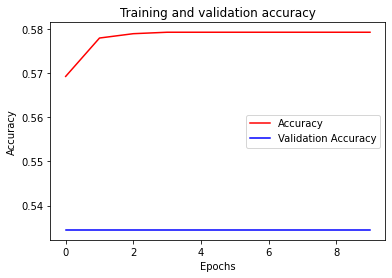

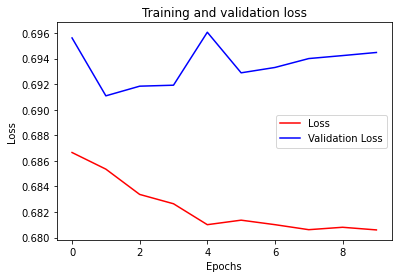

<Figure size 432x288 with 0 Axes>

In [19]:
from src.visualization.plot_hisotry import plot_history

plot_history(history)